<a href="https://colab.research.google.com/github/jostina/-week-8-wdi-life-expectancy-capstone/blob/main/Week_8_Data_Science_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Project Title and Objective


WEEK 8 DATA SCIENCE CAPSTONE PROJECT
AnalystLab Africa Data Science Internship


Project Title: Predicting Life Expectancy in African Countries
Using World Bank World Development Indicators

Research Question: Can we predict a country's life expectancy using
socioeconomic, health, education, infrastructure,
demographic, and technology indicators?

Target Variable:
Life expectancy at birth, total (years)
Indicator Code: SP.DYN.LE00.IN

#2. Import Libraries

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


#3. Load the Dataset

In [3]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

file_path = "/content/WDICSV.csv"

wdi = pd.read_csv(
    file_path,
    low_memory=False
)

print("Dataset loaded successfully.")
print("Shape:", wdi.shape)

display(wdi.head())

Dataset loaded successfully.
Shape: (396970, 70)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,18.685118,19.205632,19.742772,20.332679,20.862800,21.419621,21.996456,22.541440,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.606712,7.926604,8.309896,8.704591,9.106640,9.480804,9.903209,10.288154,NaN,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,39.052626,39.321068,39.649534,39.968299,40.354628,40.723805,41.026351,41.289974,NaN,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.742043,50.667516,52.598171,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,24.584906,25.375037,26.941984,28.983183,30.909991,32.709837,33.998179,35.240236,36.080572,NaN


#4. Understand the Dataset

In [4]:
# ============================================================
# 3. DATASET OVERVIEW
# ============================================================

print("Number of rows:", wdi.shape[0])
print("Number of columns:", wdi.shape[1])

print("\nNumber of countries/economies:")
print(wdi["Country Name"].nunique())

print("\nNumber of indicators:")
print(wdi["Indicator Name"].nunique())

print("\nYears available:")
year_columns = [
    col for col in wdi.columns
    if str(col).isdigit()
]

print(year_columns[0], "to", year_columns[-1])
print("Number of years:", len(year_columns))

Number of rows: 396970
Number of columns: 70

Number of countries/economies:
265

Number of indicators:
1498

Years available:
1960 to 2025
Number of years: 66


#5. Check Data Types

In [5]:
# ============================================================
# 4. DATA TYPES
# ============================================================

wdi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396970 entries, 0 to 396969
Data columns (total 70 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    396970 non-null  object 
 1   Country Code    396970 non-null  object 
 2   Indicator Name  396970 non-null  object 
 3   Indicator Code  396970 non-null  object 
 4   1960            37226 non-null   float64
 5   1961            42560 non-null   float64
 6   1962            43847 non-null   float64
 7   1963            44777 non-null   float64
 8   1964            45283 non-null   float64
 9   1965            47096 non-null   float64
 10  1966            47354 non-null   float64
 11  1967            47991 non-null   float64
 12  1968            48608 non-null   float64
 13  1969            49391 non-null   float64
 14  1970            72137 non-null   float64
 15  1971            76468 non-null   float64
 16  1972            78158 non-null   float64
 17  1973      

#6. Check Duplicates

In [6]:
# ============================================================
# 5. DUPLICATE CHECK
# ============================================================

duplicate_count = wdi.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


#7. Examine Available Indicators

In [7]:
# ============================================================
# 6. INDICATOR EXPLORATION
# ============================================================

indicators = wdi[
    ["Indicator Name", "Indicator Code"]
].drop_duplicates()

print("Total unique indicators:", len(indicators))

display(indicators.head(20))

Total unique indicators: 1498


,Indicator Name,Indicator Code
0,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS
1,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS
2,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS
3,Access to electricity (% of population),EG.ELC.ACCS.ZS
4,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS
5,"Access to electricity, urban (% of urban popul...",EG.ELC.ACCS.UR.ZS
6,Account ownership at a financial institution o...,FX.OWN.TOTL.ZS
7,Account ownership at a financial institution o...,FX.OWN.TOTL.FE.ZS
8,Account ownership at a financial institution o...,FX.OWN.TOTL.MA.ZS
9,Account ownership at a financial institution o...,FX.OWN.TOTL.OL.ZS


In [8]:
# Search indicator names containing specific words

search_terms = [
    "life expectancy",
    "GDP per capita",
    "health expenditure",
    "physicians",
    "mortality",
    "fertility",
    "electricity",
    "internet",
    "unemployment",
    "CO2",
    "literacy"
]

for term in search_terms:
    result = indicators[
        indicators["Indicator Name"]
        .str.contains(term, case=False, na=False)
    ]

    print(f"\n--- {term} ---")
    display(result.head(10))


--- life expectancy ---


,Indicator Name,Indicator Code
744,"Life expectancy at birth, female (years)",SP.DYN.LE00.FE.IN
745,"Life expectancy at birth, male (years)",SP.DYN.LE00.MA.IN
746,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN



--- GDP per capita ---


,Indicator Name,Indicator Code
515,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD
516,GDP per capita (constant LCU),NY.GDP.PCAP.KN
517,GDP per capita (current LCU),NY.GDP.PCAP.CN
518,GDP per capita (current US$),NY.GDP.PCAP.CD
519,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG
520,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD
521,"GDP per capita, PPP (current international $)",NY.GDP.PCAP.PP.CD
559,"Government expenditure per student, primary (%...",SE.XPD.PRIM.PC.ZS
560,"Government expenditure per student, secondary ...",SE.XPD.SECO.PC.ZS
561,"Government expenditure per student, tertiary (...",SE.XPD.TERT.PC.ZS



--- health expenditure ---


...

,Indicator Name,Indicator Code
18,Adequacy of unemployment benefits and ALMP (% ...,per_lm_alllm.adq_pop_tot
114,Benefit incidence of unemployment benefits and...,per_lm_alllm.ben_q1_tot
292,Coverage of unemployment benefits and ALMP (% ...,per_lm_alllm.cov_pop_tot
293,Coverage of unemployment benefits and ALMP in ...,per_lm_alllm.cov_q2_tot
294,Coverage of unemployment benefits and ALMP in ...,per_lm_alllm.cov_q3_tot
295,Coverage of unemployment benefits and ALMP in ...,per_lm_alllm.cov_q4_tot
296,Coverage of unemployment benefits and ALMP in ...,per_lm_alllm.cov_q1_tot
297,Coverage of unemployment benefits and ALMP in ...,per_lm_alllm.cov_q5_tot
1439,Unemployment with advanced education (% of tot...,SL.UEM.ADVN.ZS
1440,"Unemployment with advanced education, female (...",SL.UEM.ADVN.FE.ZS



--- CO2 ---


,Indicator Name,Indicator Code
174,Carbon dioxide (CO2) emissions (total) excludi...,EN.GHG.CO2.ZG.AR5
175,Carbon dioxide (CO2) emissions (total) excludi...,EN.GHG.CO2.MT.CE.AR5
176,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5
177,Carbon dioxide (CO2) emissions from Agricultur...,EN.GHG.CO2.AG.MT.CE.AR5
178,Carbon dioxide (CO2) emissions from Building (...,EN.GHG.CO2.BU.MT.CE.AR5
179,Carbon dioxide (CO2) emissions from Fugitive E...,EN.GHG.CO2.FE.MT.CE.AR5
180,Carbon dioxide (CO2) emissions from Industrial...,EN.GHG.CO2.IC.MT.CE.AR5
181,Carbon dioxide (CO2) emissions from Industrial...,EN.GHG.CO2.IP.MT.CE.AR5
182,Carbon dioxide (CO2) emissions from Power Indu...,EN.GHG.CO2.PI.MT.CE.AR5
183,Carbon dioxide (CO2) emissions from Transport ...,EN.GHG.CO2.TR.MT.CE.AR5



--- literacy ---


,Indicator Name,Indicator Code
751,"Literacy rate, adult female (% of females ages...",SE.ADT.LITR.FE.ZS
752,"Literacy rate, adult male (% of males ages 15 ...",SE.ADT.LITR.MA.ZS
753,"Literacy rate, adult total (% of people ages 1...",SE.ADT.LITR.ZS
754,"Literacy rate, youth (ages 15-24), gender pari...",SE.ADT.1524.LT.FM.ZS
755,"Literacy rate, youth female (% of females ages...",SE.ADT.1524.LT.FE.ZS
756,"Literacy rate, youth male (% of males ages 15-24)",SE.ADT.1524.LT.MA.ZS
757,"Literacy rate, youth total (% of people ages 1...",SE.ADT.1524.LT.ZS


#8. Define African Countries

In [9]:
# ============================================================
# 7. AFRICAN COUNTRIES
# ============================================================

africa_codes = [
    "DZA", "AGO", "BEN", "BWA", "BFA", "BDI",
    "CPV", "CMR", "CAF", "TCD", "COM", "COG",
    "COD", "CIV", "DJI", "EGY", "GNQ", "ERI",
    "SWZ", "ETH", "GAB", "GMB", "GHA", "GIN",
    "GNB", "KEN", "LSO", "LBR", "LBY", "MDG",
    "MWI", "MLI", "MRT", "MUS", "MAR", "MOZ",
    "NAM", "NER", "NGA", "RWA", "STP", "SEN",
    "SYC", "SLE", "SOM", "ZAF", "SSD", "SDN",
    "TZA", "TGO", "TUN", "UGA", "ZMB", "ZWE"
]

africa = wdi[
    wdi["Country Code"].isin(africa_codes)
].copy()

print("African countries found:", africa["Country Name"].nunique())
print("Rows:", len(africa))

display(
    africa[
        ["Country Name", "Country Code"]
    ].drop_duplicates().sort_values("Country Name")
)

African countries found: 54
Rows: 80892


,Country Name,Country Code
74900,Algeria,DZA
79394,Angola,AGO
101864,Benin,BEN
109354,Botswana,BWA
116844,Burkina Faso,BFA
118342,Burundi,BDI
119840,Cabo Verde,CPV
122836,Cameroon,CMR
127330,Central African Republic,CAF
128828,Chad,TCD


#9. Select Indicators

In [10]:
# ============================================================
# 8. SELECT INDICATORS
# ============================================================

indicator_codes = {
    "life_expectancy": "SP.DYN.LE00.IN",
    "gdp_per_capita": "NY.GDP.PCAP.CD",
    "gdp_growth": "NY.GDP.MKTP.KD.ZG",
    "health_expenditure": "SH.XPD.CHEX.GD.ZS",
    "physicians": "SH.MED.PHYS.ZS",
    "infant_mortality": "SP.DYN.IMRT.IN",
    "fertility": "SP.DYN.TFRT.IN",
    "literacy": "SE.ADT.LITR.ZS",
    "electricity_access": "EG.ELC.ACCS.ZS",
    "internet_usage": "IT.NET.USER.ZS",
    "unemployment": "SL.UEM.TOTL.ZS",
    "co2_per_capita": "EN.ATM.CO2E.PC",
    "population_growth": "SP.POP.GROW"
}

indicator_codes

{'life_expectancy': 'SP.DYN.LE00.IN',
 'gdp_per_capita': 'NY.GDP.PCAP.CD',
 'gdp_growth': 'NY.GDP.MKTP.KD.ZG',
 'health_expenditure': 'SH.XPD.CHEX.GD.ZS',
 'physicians': 'SH.MED.PHYS.ZS',
 'infant_mortality': 'SP.DYN.IMRT.IN',
 'fertility': 'SP.DYN.TFRT.IN',
 'literacy': 'SE.ADT.LITR.ZS',
 'electricity_access': 'EG.ELC.ACCS.ZS',
 'internet_usage': 'IT.NET.USER.ZS',
 'unemployment': 'SL.UEM.TOTL.ZS',
 'co2_per_capita': 'EN.ATM.CO2E.PC',
 'population_growth': 'SP.POP.GROW'}

#10. Verify the Indicators Exist

In [11]:
# ============================================================
# 9. VERIFY INDICATORS
# ============================================================

available_codes = set(wdi["Indicator Code"].unique())

available_indicators = {}
missing_indicators = {}

for name, code in indicator_codes.items():
    if code in available_codes:
        available_indicators[name] = code
    else:
        missing_indicators[name] = code

print("Available indicators:")
for name, code in available_indicators.items():
    print(f"{name}: {code}")

print("\nMissing indicators:")
for name, code in missing_indicators.items():
    print(f"{name}: {code}")

Available indicators:
life_expectancy: SP.DYN.LE00.IN
gdp_per_capita: NY.GDP.PCAP.CD
gdp_growth: NY.GDP.MKTP.KD.ZG
health_expenditure: SH.XPD.CHEX.GD.ZS
physicians: SH.MED.PHYS.ZS
infant_mortality: SP.DYN.IMRT.IN
fertility: SP.DYN.TFRT.IN
literacy: SE.ADT.LITR.ZS
electricity_access: EG.ELC.ACCS.ZS
internet_usage: IT.NET.USER.ZS
unemployment: SL.UEM.TOTL.ZS
population_growth: SP.POP.GROW

Missing indicators:
co2_per_capita: EN.ATM.CO2E.PC


#11. Create the Analytical Dataset

In [12]:
# ============================================================
# 10. CREATE ANALYTICAL DATASET
# ============================================================

selected_codes = list(available_indicators.values())

selected_wdi = africa[
    africa["Indicator Code"].isin(selected_codes)
].copy()

# Keep only necessary columns
id_columns = [
    "Country Name",
    "Country Code",
    "Indicator Name",
    "Indicator Code"
]

year_columns = [
    col for col in wdi.columns
    if str(col).isdigit()
]

selected_wdi = selected_wdi[
    id_columns + year_columns
]

print("Selected WDI shape:", selected_wdi.shape)

Selected WDI shape: (648, 70)


#12. Reshape the Dataset

In [13]:
# ============================================================
# 11. RESHAPE WIDE DATA TO LONG FORMAT
# ============================================================

long_df = selected_wdi.melt(
    id_vars=id_columns,
    value_vars=year_columns,
    var_name="Year",
    value_name="Value"
)

long_df["Year"] = long_df["Year"].astype(int)

print("Long-format shape:", long_df.shape)

display(long_df.head())

Long-format shape: (42768, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
0,Algeria,DZA,Access to electricity (% of population),EG.ELC.ACCS.ZS,1960,NaN
1,Algeria,DZA,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,1960,NaN
2,Algeria,DZA,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,1960,7.503000
3,Algeria,DZA,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,1960,NaN
4,Algeria,DZA,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,238.392477


#13. Convert Indicators Into Columns

In [14]:
# ============================================================
# 12. PIVOT INDICATORS
# ============================================================

model_df = long_df.pivot_table(
    index=[
        "Country Name",
        "Country Code",
        "Year"
    ],
    columns="Indicator Code",
    values="Value"
).reset_index()

model_df.columns.name = None

print("Model dataset shape:", model_df.shape)

display(model_df.head())

Model dataset shape: (3564, 15)


,Country Name,Country Code,Year,EG.ELC.ACCS.ZS,IT.NET.USER.ZS,NY.GDP.MKTP.KD.ZG,NY.GDP.PCAP.CD,SE.ADT.LITR.ZS,SH.MED.PHYS.ZS,SH.XPD.CHEX.GD.ZS,SL.UEM.TOTL.ZS,SP.DYN.IMRT.IN,SP.DYN.LE00.IN,SP.DYN.TFRT.IN,SP.POP.GROW
0,Algeria,DZA,1960,NaN,NaN,NaN,238.392477,NaN,0.173,NaN,NaN,162.0,40.839,7.503,NaN
1,Algeria,DZA,1961,NaN,NaN,-13.605441,209.370673,NaN,NaN,NaN,NaN,161.5,40.792,7.564,1.769481
2,Algeria,DZA,1962,NaN,NaN,-19.685042,169.602863,NaN,NaN,NaN,NaN,161.3,39.527,7.607,1.467295
3,Algeria,DZA,1963,NaN,NaN,34.313729,225.584660,NaN,NaN,NaN,NaN,161.5,43.143,7.649,1.525050
4,Algeria,DZA,1964,NaN,NaN,5.839413,238.863802,NaN,NaN,NaN,NaN,161.7,42.987,7.672,1.636454


#14. Rename Columns

In [15]:
# ============================================================
# 13. RENAME FEATURES
# ============================================================

reverse_mapping = {
    code: name
    for name, code in available_indicators.items()
}

model_df = model_df.rename(
    columns=reverse_mapping
)

display(model_df.head())

,Country Name,Country Code,Year,electricity_access,internet_usage,gdp_growth,gdp_per_capita,literacy,physicians,health_expenditure,unemployment,infant_mortality,life_expectancy,fertility,population_growth
0,Algeria,DZA,1960,NaN,NaN,NaN,238.392477,NaN,0.173,NaN,NaN,162.0,40.839,7.503,NaN
1,Algeria,DZA,1961,NaN,NaN,-13.605441,209.370673,NaN,NaN,NaN,NaN,161.5,40.792,7.564,1.769481
2,Algeria,DZA,1962,NaN,NaN,-19.685042,169.602863,NaN,NaN,NaN,NaN,161.3,39.527,7.607,1.467295
3,Algeria,DZA,1963,NaN,NaN,34.313729,225.584660,NaN,NaN,NaN,NaN,161.5,43.143,7.649,1.525050
4,Algeria,DZA,1964,NaN,NaN,5.839413,238.863802,NaN,NaN,NaN,NaN,161.7,42.987,7.672,1.636454


#15. Check Missing Values

In [16]:
# ============================================================
# 14. MISSING VALUE ANALYSIS
# ============================================================

missing_summary = pd.DataFrame({
    "Missing Values": model_df.isnull().sum(),
    "Missing Percentage": (
        model_df.isnull().mean() * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

display(missing_summary)

,Missing Values,Missing Percentage
literacy,3261,91.50
physicians,2479,69.56
health_expenditure,2308,64.76
electricity_access,2003,56.20
internet_usage,1966,55.16
unemployment,1714,48.09
gdp_growth,415,11.64
gdp_per_capita,310,8.70
infant_mortality,275,7.72
population_growth,55,1.54


#16. Restrict the Time Period

In [17]:
# ============================================================
# 15. SELECT MODERN TIME PERIOD
# ============================================================

model_df = model_df[
    model_df["Year"] >= 2000
].copy()

print("Shape after selecting years from 2000:")
print(model_df.shape)

print(
    "Years:",
    model_df["Year"].min(),
    "to",
    model_df["Year"].max()
)

Shape after selecting years from 2000:
(1404, 15)
Years: 2000 to 2025


#17. Remove Rows Without the Target

In [18]:
# ============================================================
# 16. TARGET CLEANING
# ============================================================

target = "life_expectancy"

before = len(model_df)

model_df = model_df.dropna(
    subset=[target]
).copy()

after = len(model_df)

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 1404
Rows after: 1350
Rows removed: 54


#18. Feature Engineering

In [19]:
# ============================================================
# 17. FEATURE ENGINEERING
# ============================================================

if "gdp_per_capita" in model_df.columns:

    model_df["log_gdp_per_capita"] = np.log1p(
        model_df["gdp_per_capita"].clip(lower=0)
    )

    print("Created log_gdp_per_capita.")

Created log_gdp_per_capita.


#19. Check the Final Dataset

In [20]:
# ============================================================
# 18. FINAL DATASET INSPECTION
# ============================================================

print(model_df.info())

display(
    model_df.describe().T
)

<class 'pandas.core.frame.DataFrame'>
Index: 1350 entries, 40 to 3562
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country Name        1350 non-null   object 
 1   Country Code        1350 non-null   object 
 2   Year                1350 non-null   int64  
 3   electricity_access  1334 non-null   float64
 4   internet_usage      1297 non-null   float64
 5   gdp_growth          1305 non-null   float64
 6   gdp_per_capita      1320 non-null   float64
 7   literacy            247 non-null    float64
 8   physicians          606 non-null    float64
 9   health_expenditure  1256 non-null   float64
 10  unemployment        1322 non-null   float64
 11  infant_mortality    1350 non-null   float64
 12  life_expectancy     1350 non-null   float64
 13  fertility           1350 non-null   float64
 14  population_growth   1349 non-null   float64
 15  log_gdp_per_capita  1320 non-null   float64
dtypes: float64

,count,mean,std,min,25%,50%,75%,max
Year,1350.0,2012.000000,7.213775,2000.000000,2006.000000,2012.000000,2018.000000,2024.000000
electricity_access,1334.0,46.112744,29.521517,0.800000,19.500000,43.550000,66.100000,100.000000
internet_usage,1297.0,17.007200,20.680541,0.005902,1.700000,7.500000,25.398800,91.200000
gdp_growth,1305.0,3.981900,6.200641,-50.338515,2.099989,4.280715,6.255906,86.826748
gdp_per_capita,1320.0,2308.445680,2970.100853,109.593814,580.307181,1079.029985,2833.404740,19141.511874
literacy,247.0,63.797098,19.736514,14.380000,49.200001,67.169998,79.291580,97.269997
physicians,606.0,0.326476,0.516960,0.012000,0.062250,0.132000,0.360750,6.598000
health_expenditure,1256.0,5.040594,2.169744,1.222602,3.618593,4.574426,5.933674,22.113224
unemployment,1322.0,9.167883,7.390009,0.316000,3.230750,5.820500,14.204500,36.472000
infant_mortality,1350.0,53.212370,25.744124,7.900000,36.025000,50.300000,69.100000,239.900000


#20. Exploratory Data Analysis

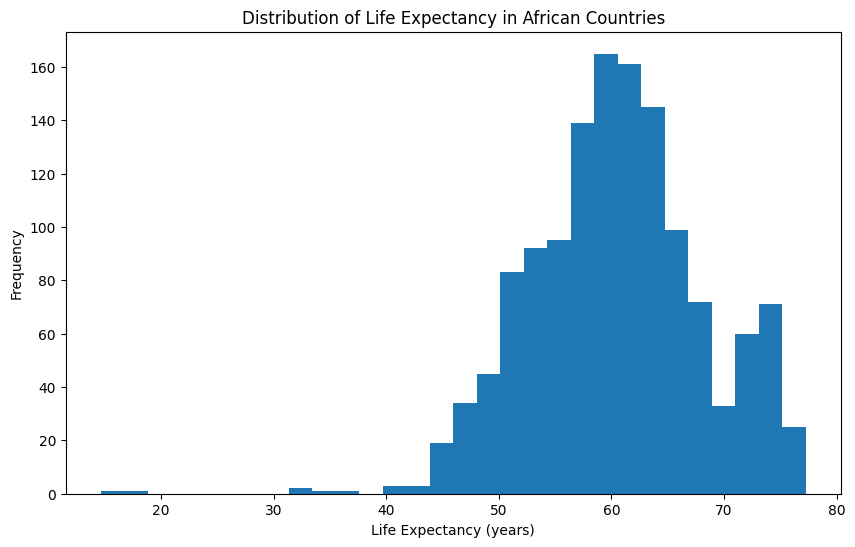

In [21]:
# ============================================================
# 19. LIFE EXPECTANCY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    model_df["life_expectancy"].dropna(),
    bins=30
)

plt.title("Distribution of Life Expectancy in African Countries")
plt.xlabel("Life Expectancy (years)")
plt.ylabel("Frequency")

plt.show()

#21. Life Expectancy Over Time

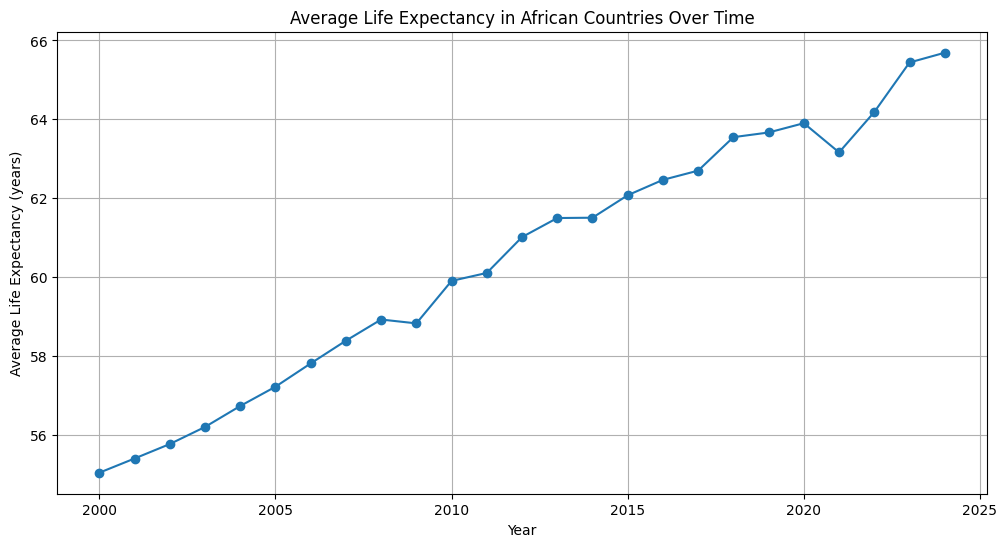

In [22]:
# ============================================================
# 20. LIFE EXPECTANCY TREND
# ============================================================

yearly_life = (
    model_df
    .groupby("Year")["life_expectancy"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_life["Year"],
    yearly_life["life_expectancy"],
    marker="o"
)

plt.title(
    "Average Life Expectancy in African Countries Over Time"
)

plt.xlabel("Year")
plt.ylabel("Average Life Expectancy (years)")

plt.grid(True)

plt.show()

#22. Country Comparison

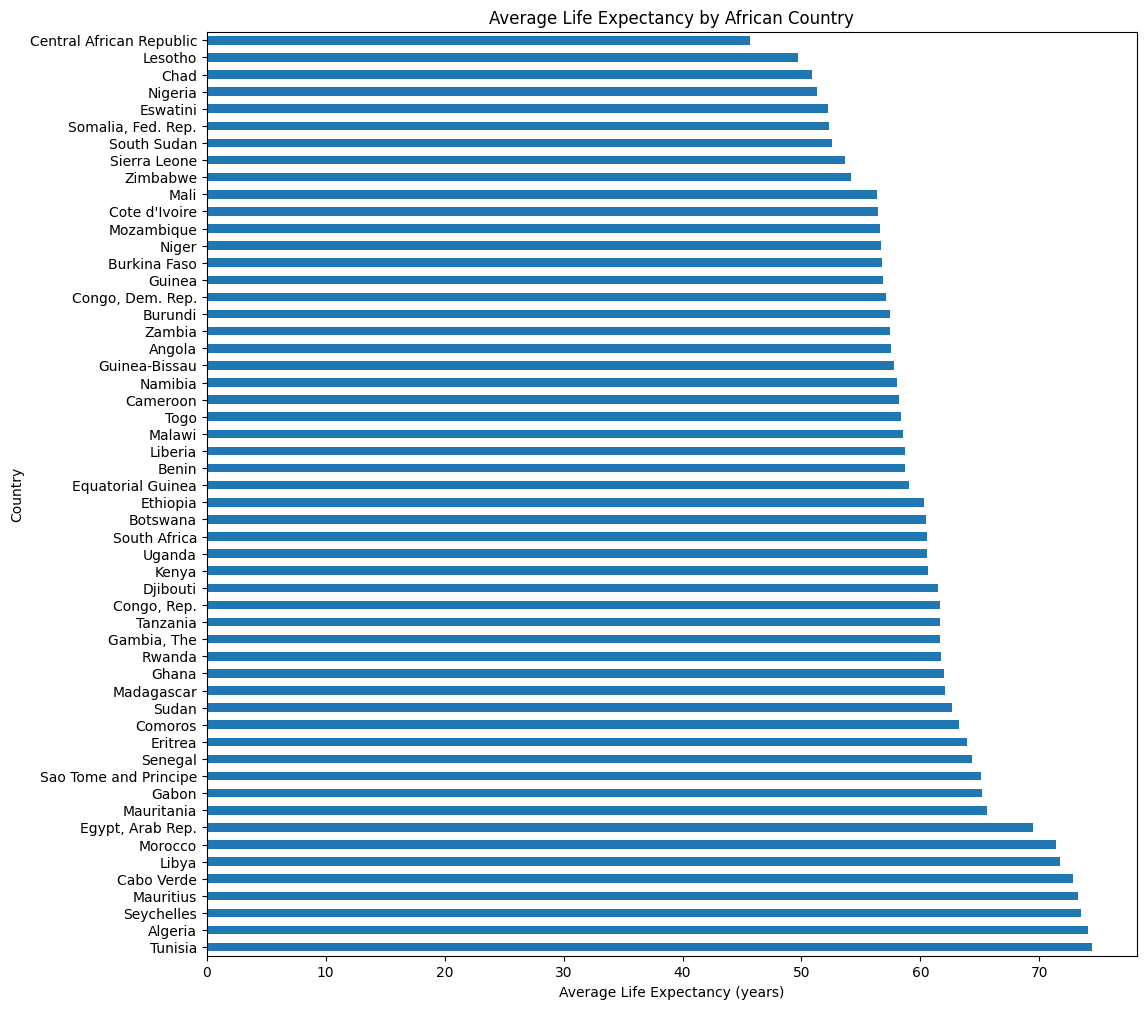

In [23]:
# ============================================================
# 21. COUNTRY LIFE EXPECTANCY COMPARISON
# ============================================================

country_life = (
    model_df
    .groupby("Country Name")["life_expectancy"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 12))

country_life.plot(
    kind="barh"
)

plt.title(
    "Average Life Expectancy by African Country"
)

plt.xlabel("Average Life Expectancy (years)")
plt.ylabel("Country")

plt.show()

#23. GDP vs Life Expectancy

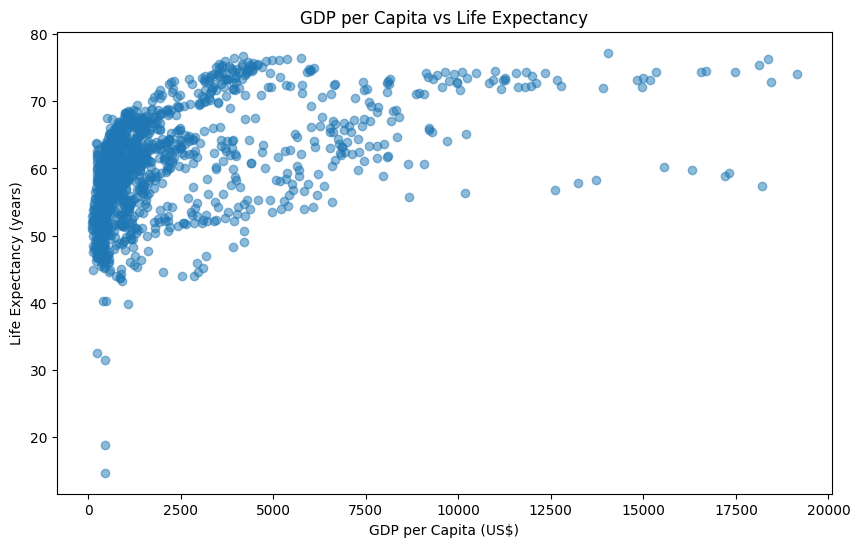

In [24]:
# ============================================================
# 22. GDP VS LIFE EXPECTANCY
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    model_df["gdp_per_capita"],
    model_df["life_expectancy"],
    alpha=0.5
)

plt.title(
    "GDP per Capita vs Life Expectancy"
)

plt.xlabel("GDP per Capita (US$)")
plt.ylabel("Life Expectancy (years)")

plt.show()

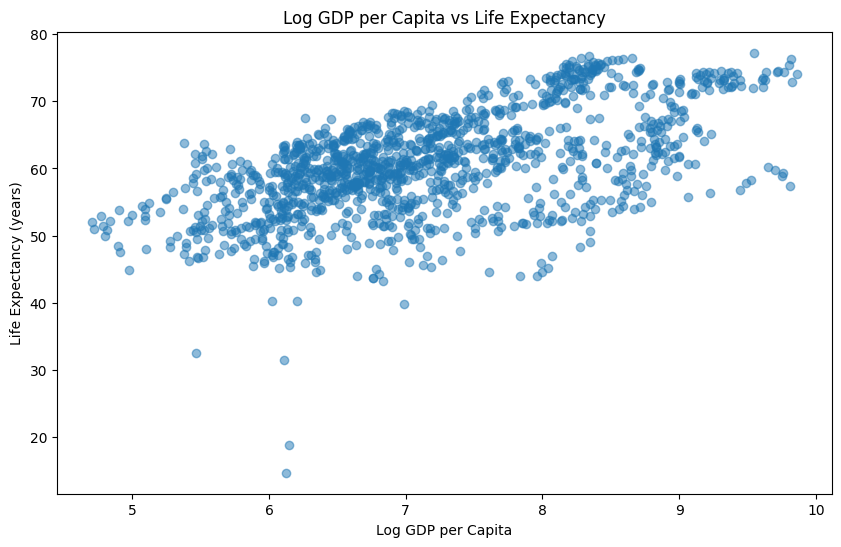

In [25]:
# ============================================================
# 23. LOG GDP VS LIFE EXPECTANCY
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    model_df["log_gdp_per_capita"],
    model_df["life_expectancy"],
    alpha=0.5
)

plt.title(
    "Log GDP per Capita vs Life Expectancy"
)

plt.xlabel("Log GDP per Capita")
plt.ylabel("Life Expectancy (years)")

plt.show()

#24. Electricity Access vs Life Expectancy

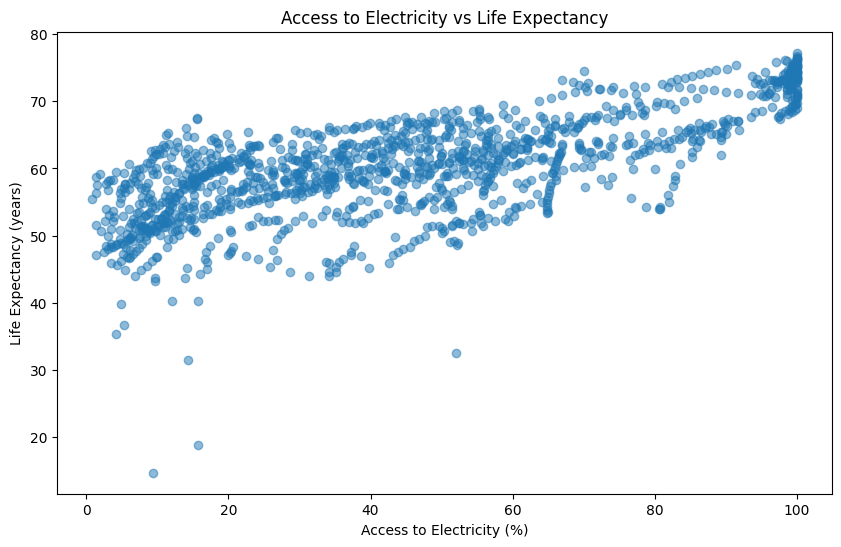

In [26]:
# ============================================================
# 24. ELECTRICITY VS LIFE EXPECTANCY
# ============================================================

if "electricity_access" in model_df.columns:

    plt.figure(figsize=(10, 6))

    plt.scatter(
        model_df["electricity_access"],
        model_df["life_expectancy"],
        alpha=0.5
    )

    plt.title(
        "Access to Electricity vs Life Expectancy"
    )

    plt.xlabel("Access to Electricity (%)")
    plt.ylabel("Life Expectancy (years)")

    plt.show()

#25. Internet Usage vs Life Expectancy

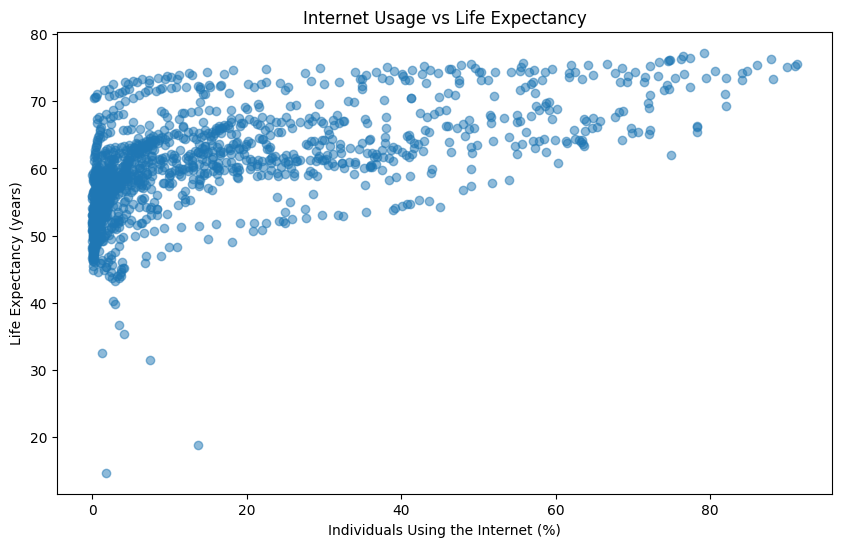

In [27]:
# ============================================================
# 25. INTERNET USAGE VS LIFE EXPECTANCY
# ============================================================

if "internet_usage" in model_df.columns:

    plt.figure(figsize=(10, 6))

    plt.scatter(
        model_df["internet_usage"],
        model_df["life_expectancy"],
        alpha=0.5
    )

    plt.title(
        "Internet Usage vs Life Expectancy"
    )

    plt.xlabel("Individuals Using the Internet (%)")
    plt.ylabel("Life Expectancy (years)")

    plt.show()

#26. Correlation Analysis

In [28]:
# ============================================================
# 26. CORRELATION ANALYSIS
# ============================================================

numeric_df = model_df.select_dtypes(
    include=np.number
)

correlations = (
    numeric_df
    .corr()["life_expectancy"]
    .sort_values(ascending=False)
)

display(correlations)

,life_expectancy
life_expectancy,1.000000
electricity_access,0.726069
internet_usage,0.594943
log_gdp_per_capita,0.577235
physicians,0.570643
gdp_per_capita,0.475827
literacy,0.460041
Year,0.413676
unemployment,0.144714
gdp_growth,-0.062459


#27. Correlation Heatmap

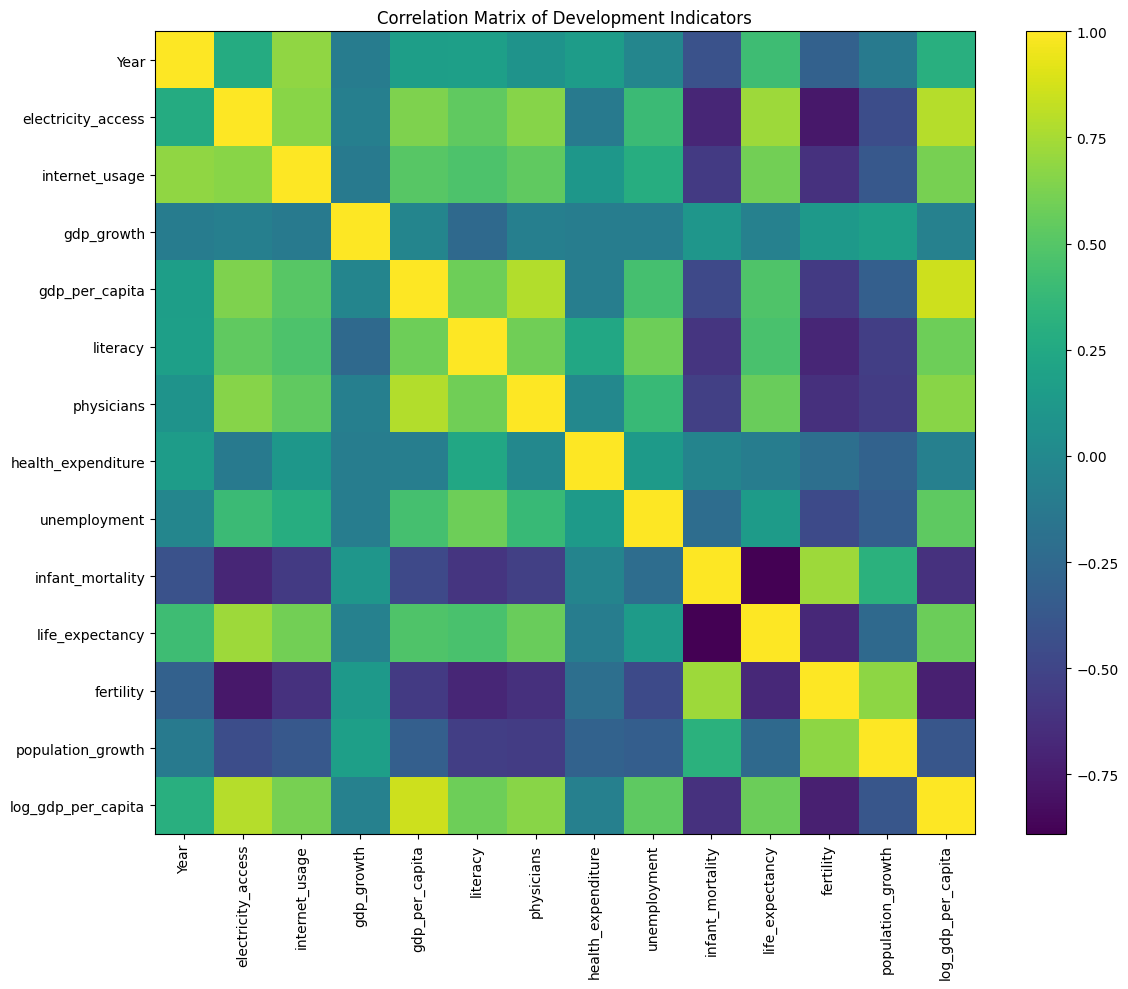

In [29]:
# ============================================================
# 27. CORRELATION HEATMAP
# ============================================================

corr = numeric_df.corr()

plt.figure(figsize=(12, 10))

plt.imshow(
    corr,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix of Development Indicators")

plt.tight_layout()

plt.show()

#28. Prepare Machine Learning Dataset

In [30]:
# ============================================================
# 28. MACHINE LEARNING DATA
# ============================================================

target = "life_expectancy"

exclude_columns = [
    "Country Name",
    "Country Code",
    target
]

feature_columns = [
    col for col in model_df.columns
    if col not in exclude_columns
]

X = model_df[feature_columns].copy()
y = model_df[target].copy()

print("Features:")
print(feature_columns)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['Year', 'electricity_access', 'internet_usage', 'gdp_growth', 'gdp_per_capita', 'literacy', 'physicians', 'health_expenditure', 'unemployment', 'infant_mortality', 'fertility', 'population_growth', 'log_gdp_per_capita']

X shape: (1350, 13)
y shape: (1350,)


#29. Remove Extremely Sparse Features

In [31]:
# ============================================================
# 29. REMOVE HIGHLY MISSING FEATURES
# ============================================================

missing_percentage = X.isnull().mean()

# Keep variables with at least 50% observed values
usable_features = missing_percentage[
    missing_percentage <= 0.50
].index.tolist()

X = X[usable_features]

print("Features retained:", len(usable_features))
print(usable_features)

Features retained: 11
['Year', 'electricity_access', 'internet_usage', 'gdp_growth', 'gdp_per_capita', 'health_expenditure', 'unemployment', 'infant_mortality', 'fertility', 'population_growth', 'log_gdp_per_capita']


#30. Train/Test Split
For a development dataset containing years, we can make the evaluation more realistic by training on earlier years and testing on later years.

We'll use 2020 onward as the test period.

In [32]:
# ============================================================
# 30. TIME-BASED TRAIN/TEST SPLIT
# ============================================================

train_data = model_df[
    model_df["Year"] < 2020
].copy()

test_data = model_df[
    model_df["Year"] >= 2020
].copy()

X_train = train_data[usable_features]
y_train = train_data[target]

X_test = test_data[usable_features]
y_test = test_data[target]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print(
    "\nTraining years:",
    train_data["Year"].min(),
    "to",
    train_data["Year"].max()
)

print(
    "Testing years:",
    test_data["Year"].min(),
    "to",
    test_data["Year"].max()
)

Training observations: 1080
Testing observations: 270

Training years: 2000 to 2019
Testing years: 2020 to 2024


#31. Create Preprocessing Pipeline

In [33]:
# ============================================================
# 31. PREPROCESSING
# ============================================================

numeric_features = usable_features

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="median")
                ),
                (
                    "scaler",
                    StandardScaler()
                )
            ]),
            numeric_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


#32. Model 1 — Linear Regression

In [34]:
# ============================================================
# 32. MODEL 1: LINEAR REGRESSION
# ============================================================

linear_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LinearRegression()
    )
])

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


#33. Model 2 — Random Forest

In [35]:
# ============================================================
# 33. MODEL 2: RANDOM FOREST REGRESSOR
# ============================================================

random_forest_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_split=5,
            random_state=42,
            n_jobs=-1
        )
    )
])

random_forest_model.fit(
    X_train,
    y_train
)

rf_predictions = random_forest_model.predict(
    X_test
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


#34. Model 3 — Gradient Boosting

In [36]:
# ============================================================
# 34. MODEL 3: GRADIENT BOOSTING REGRESSOR
# ============================================================

gradient_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    )
])

gradient_model.fit(
    X_train,
    y_train
)

gradient_predictions = gradient_model.predict(
    X_test
)

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


#35. Model Evaluation Function

In [37]:
# ============================================================
# 35. MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(name, y_true, predictions):

    mae = mean_absolute_error(
        y_true,
        predictions
    )

    mse = mean_squared_error(
        y_true,
        predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        predictions
    )

    return {
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R²": r2
    }

#36. Compare Models

In [38]:
# ============================================================
# 36. MODEL COMPARISON
# ============================================================

results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gradient_predictions
    )
)

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "RMSE"
    )
)

,Model,MAE,MSE,RMSE,R²
2,Gradient Boosting,1.742100,5.200137,2.280381,0.864930
1,Random Forest,1.752875,5.581883,2.362601,0.855014
0,Linear Regression,2.251701,7.731852,2.780621,0.799170


#37. Visualize Model Performance

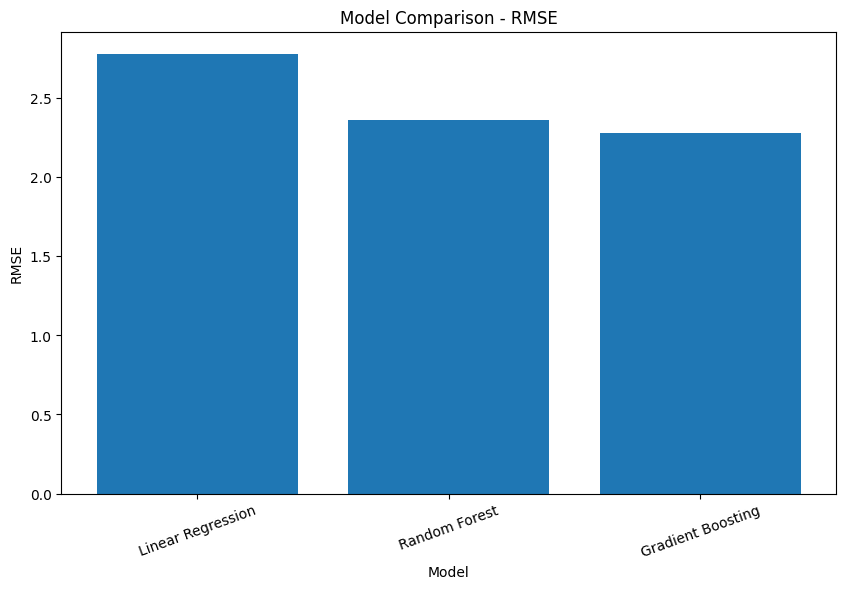

In [39]:
# ============================================================
# 37. MODEL PERFORMANCE
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.show()

#38. Actual vs Predicted

In [40]:
# ============================================================
# 38. SELECT BEST MODEL
# ============================================================

best_model_name = (
    results_df
    .sort_values("RMSE")
    .iloc[0]["Model"]
)

print("Best model:", best_model_name)

Best model: Gradient Boosting


In [41]:
# Map predictions to model names

prediction_map = {
    "Linear Regression": linear_predictions,
    "Random Forest": rf_predictions,
    "Gradient Boosting": gradient_predictions
}

best_predictions = prediction_map[
    best_model_name
]

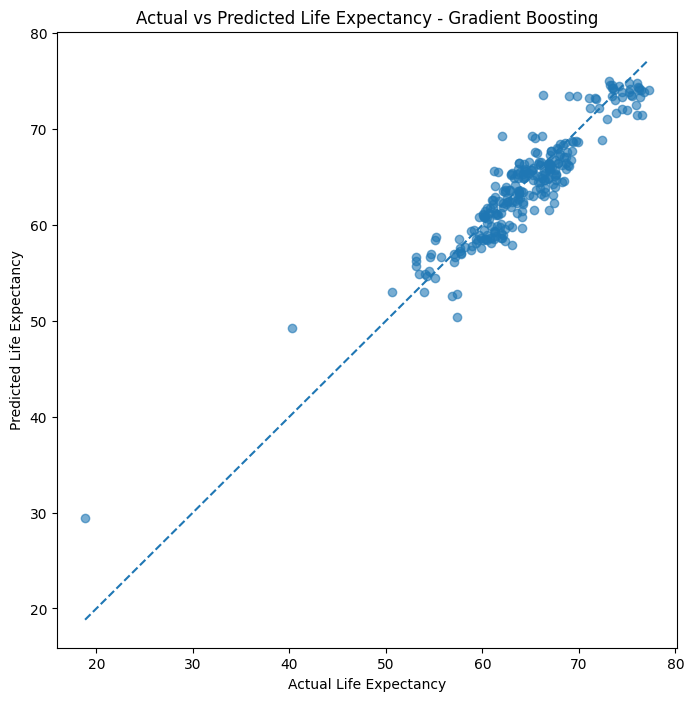

In [42]:
# ============================================================
# 39. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title(
    f"Actual vs Predicted Life Expectancy - {best_model_name}"
)

plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")

plt.show()

#39. Prediction Error Analysis

In [43]:
# ============================================================
# 40. PREDICTION ERRORS
# ============================================================

error_df = test_data[
    [
        "Country Name",
        "Country Code",
        "Year",
        target
    ]
].copy()

error_df["Predicted"] = best_predictions

error_df["Error"] = (
    error_df[target]
    - error_df["Predicted"]
)

error_df["Absolute Error"] = (
    error_df["Error"].abs()
)

display(
    error_df.sort_values(
        "Absolute Error",
        ascending=False
    ).head(20)
)

,Country Name,Country Code,Year,life_expectancy,Predicted,Error,Absolute Error
590,Central African Republic,CAF,2022,18.818,29.412699,-10.594699,10.594699
589,Central African Republic,CAF,2021,40.279,49.271076,-8.992076,8.992076
3031,South Africa,ZAF,2021,62.010,69.269588,-7.259588,7.259588
3034,South Africa,ZAF,2024,66.312,73.529558,-7.217558,7.217558
591,Central African Republic,CAF,2023,57.408,50.411695,6.996305,6.996305
1316,Ethiopia,ETH,2022,66.897,61.571575,5.325425,5.325425
1250,Eswatini,SWZ,2022,63.028,57.877645,5.150355,5.150355
2439,Namibia,NAM,2023,67.385,62.294039,5.090961,5.090961
3363,Tunisia,TUN,2023,76.508,71.504009,5.003991,5.003991
1779,Lesotho,LSO,2023,57.375,52.769668,4.605332,4.605332


#40. Feature Importance

In [44]:
# ============================================================
# 41. FEATURE IMPORTANCE
# ============================================================

if best_model_name == "Random Forest":

    fitted_model = random_forest_model.named_steps["model"]

elif best_model_name == "Gradient Boosting":

    fitted_model = gradient_model.named_steps["model"]

else:

    fitted_model = None

In [45]:
if fitted_model is not None:

    importance_df = pd.DataFrame({
        "Feature": usable_features,
        "Importance": fitted_model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        "Importance",
        ascending=False
    )

    display(importance_df)

,Feature,Importance
7,infant_mortality,0.783385
9,population_growth,0.069631
8,fertility,0.045642
1,electricity_access,0.043201
6,unemployment,0.021180
5,health_expenditure,0.019009
0,Year,0.005018
4,gdp_per_capita,0.003683
2,internet_usage,0.003562
10,log_gdp_per_capita,0.003080


#41. Plot Feature Importance

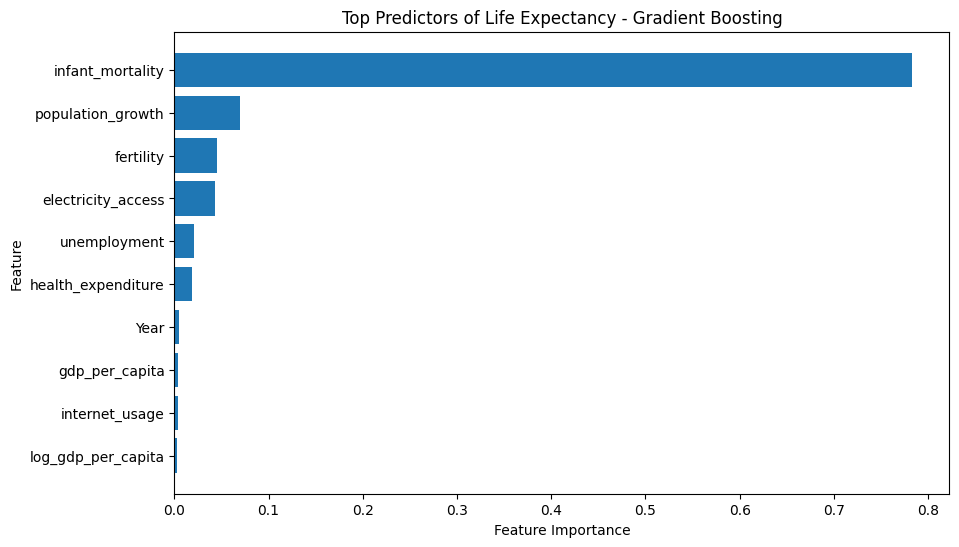

In [46]:
# ============================================================
# 42. FEATURE IMPORTANCE VISUALIZATION
# ============================================================

if fitted_model is not None:

    top_features = importance_df.head(10)

    plt.figure(figsize=(10, 6))

    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    plt.gca().invert_yaxis()

    plt.title(
        f"Top Predictors of Life Expectancy - {best_model_name}"
    )

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")

    plt.show()

#42. Save the Best Model

In [47]:
# ============================================================
# 43. SAVE BEST MODEL
# ============================================================

model_map = {
    "Linear Regression": linear_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_model
}

best_model = model_map[
    best_model_name
]

joblib.dump(
    best_model,
    "life_expectancy_model.joblib"
)

print(
    "Model saved as: life_expectancy_model.joblib"
)

Model saved as: life_expectancy_model.joblib


#43. Save Feature Information

In [48]:
# ============================================================
# 44. SAVE MODEL METADATA
# ============================================================

metadata = {
    "model_name": best_model_name,
    "target": target,
    "features": usable_features,
    "training_year_start": int(
        train_data["Year"].min()
    ),
    "training_year_end": int(
        train_data["Year"].max()
    ),
    "testing_year_start": int(
        test_data["Year"].min()
    ),
    "testing_year_end": int(
        test_data["Year"].max()
    )
}

joblib.dump(
    metadata,
    "model_metadata.joblib"
)

print("Model metadata saved.")

Model metadata saved.


#44. Final Model Results

In [49]:
# ============================================================
# 45. FINAL RESULTS
# ============================================================

best_result = (
    results_df[
        results_df["Model"] == best_model_name
    ]
)

display(best_result)

,Model,MAE,MSE,RMSE,R²
2,Gradient Boosting,1.7421,5.200137,2.280381,0.86493


#45. Automatically Generate Key Findings

In [50]:
# ============================================================
# 46. KEY FINDINGS
# ============================================================

print("================================================")
print("KEY PROJECT FINDINGS")
print("================================================")

print(
    f"\nBest-performing model: {best_model_name}"
)

print(
    f"MAE: {best_result['MAE'].iloc[0]:.3f} years"
)

print(
    f"RMSE: {best_result['RMSE'].iloc[0]:.3f} years"
)

print(
    f"R²: {best_result['R²'].iloc[0]:.3f}"
)

print(
    f"\nNumber of African countries: "
    f"{model_df['Country Name'].nunique()}"
)

print(
    f"Analysis period: "
    f"{model_df['Year'].min()}–"
    f"{model_df['Year'].max()}"
)

KEY PROJECT FINDINGS

Best-performing model: Gradient Boosting
MAE: 1.742 years
RMSE: 2.280 years
R²: 0.865

Number of African countries: 54
Analysis period: 2000–2024


#46. Export Results

In [51]:
# ============================================================
# 47. EXPORT RESULTS
# ============================================================

results_df.to_csv(
    "model_comparison.csv",
    index=False
)

error_df.to_csv(
    "prediction_errors.csv",
    index=False
)

if fitted_model is not None:
    importance_df.to_csv(
        "feature_importance.csv",
        index=False
    )

print("Results exported successfully.")

Results exported successfully.


#47. Final Project Conclusion Cell

In [52]:
# ============================================================
# 48. PROJECT CONCLUSION
# ============================================================

print("""
CONCLUSION

This project investigated whether life expectancy in African
countries can be predicted using socioeconomic, health,
education, infrastructure, demographic, environmental, and
technology indicators from the World Bank World Development
Indicators dataset.

Multiple regression models were developed and compared,
including Linear Regression, Random Forest Regression, and
Gradient Boosting Regression.

The models were evaluated using Mean Absolute Error (MAE),
Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and
R².

The best-performing model was selected based on the lowest
RMSE and its ability to generalize to more recent observations.

The analysis provides a data-driven approach for understanding
the relationship between development conditions and life
expectancy across African countries.

The results can support further investigation into health,
economic, education, infrastructure, and development policies.
""")


CONCLUSION

This project investigated whether life expectancy in African
countries can be predicted using socioeconomic, health,
education, infrastructure, demographic, environmental, and
technology indicators from the World Bank World Development
Indicators dataset.

Multiple regression models were developed and compared,
including Linear Regression, Random Forest Regression, and
Gradient Boosting Regression.

The models were evaluated using Mean Absolute Error (MAE),
Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and
R².

The best-performing model was selected based on the lowest
RMSE and its ability to generalize to more recent observations.

The analysis provides a data-driven approach for understanding
the relationship between development conditions and life
expectancy across African countries.

The results can support further investigation into health,
economic, education, infrastructure, and development policies.

